   Batsman  Runs   Mins   BF  4s  6s      SR  Pos Dismissal  Inns
0        1    33   78.0   56   5   0   58.92    3    caught     2
1        1    33   77.0   49   6   0   67.34    3    caught     4
2        1   215  503.0  346  25   1   62.13    3       lbw     1
3        1    58   67.0   48   9   0  120.83    3    bowled     3
4        1     7   26.0   18   1   0   38.88    3    caught     1
              Runs
Batsman           
1        60.877193
2        57.557692
3        49.078125
4        49.406780
5        53.026316
6        35.769231


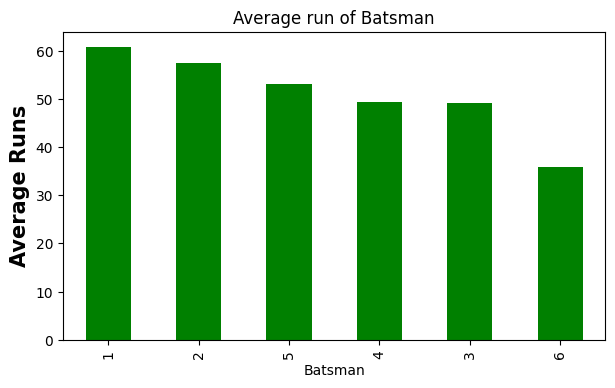

         fours  sixes  Runs  runByFour  runBySix  totalRunFromBoundary
Batsman                                                               
1          382     10  3470       1528        60                  1588
2          315      9  2993       1260        54                  1314
3          388      7  3141       1552        42                  1594
4          348     21  2915       1392       126                  1518
5          237      6  2015        948        36                   984
6          102      6   930        408        36                   444


<Figure size 1000x700 with 0 Axes>

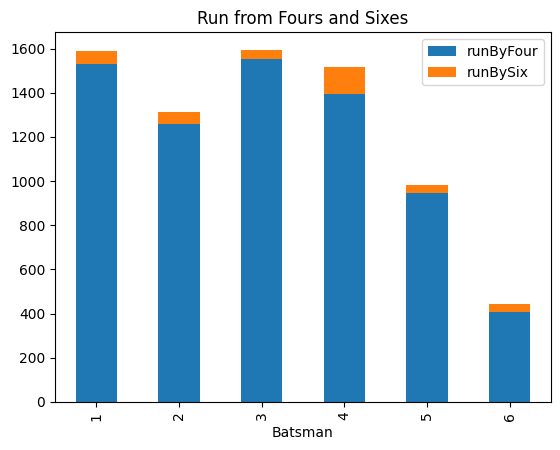

Average of Batsman 1: 60.87719298245614
Maximum of Batsman 1 in a Match: 239


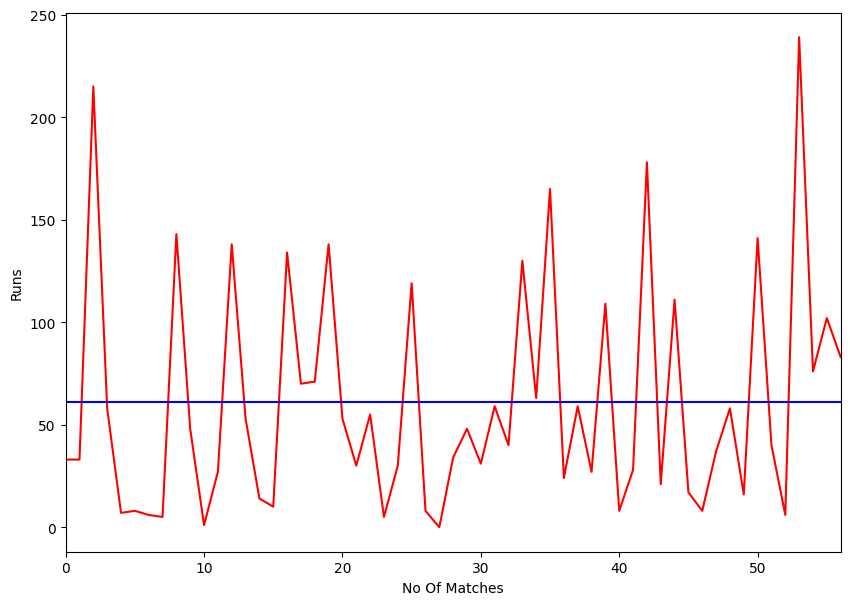

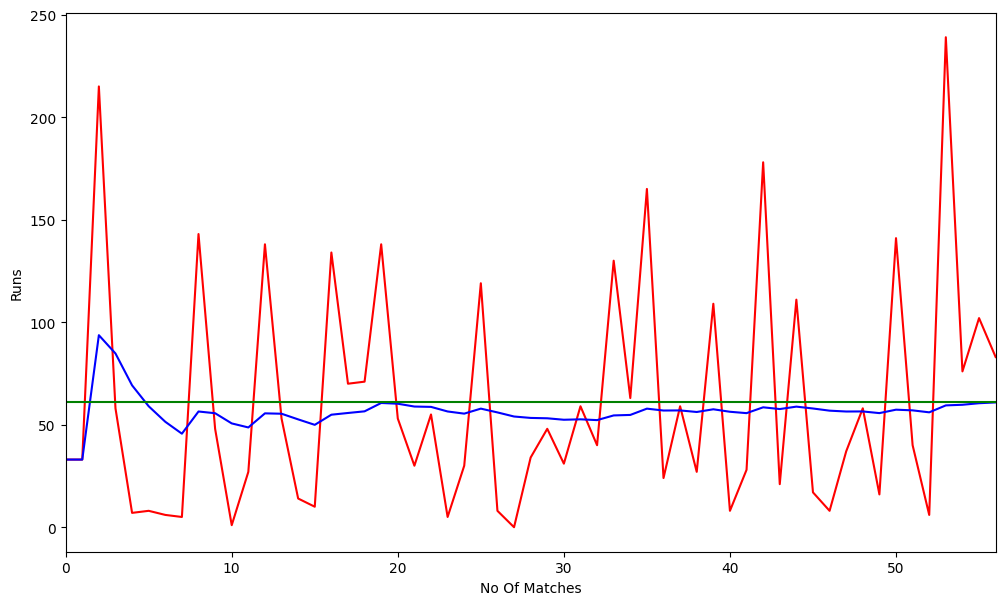

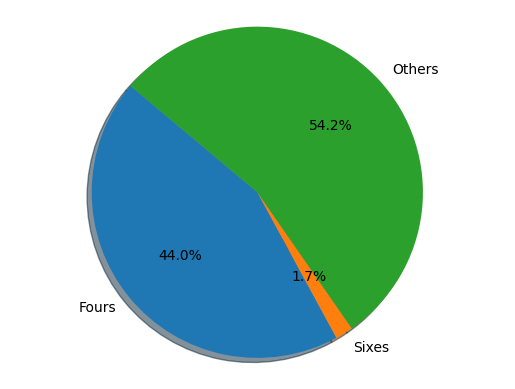

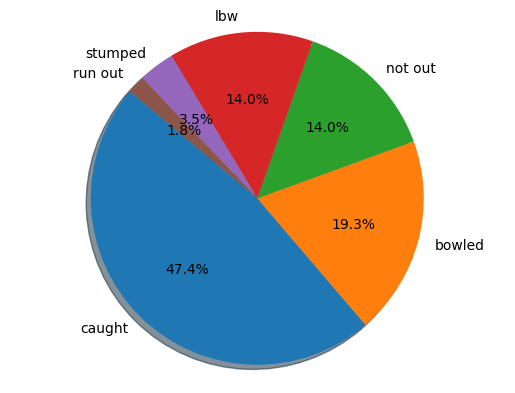

--- Position 3 ---
Matches: 25
Average: 58.44
Total Runs: 1461
Average Strike Rate: 70.8776 

--- Position 4 ---
Matches: 30
Average: 65.7
Total Runs: 1971
Average Strike Rate: 55.248666666666665 



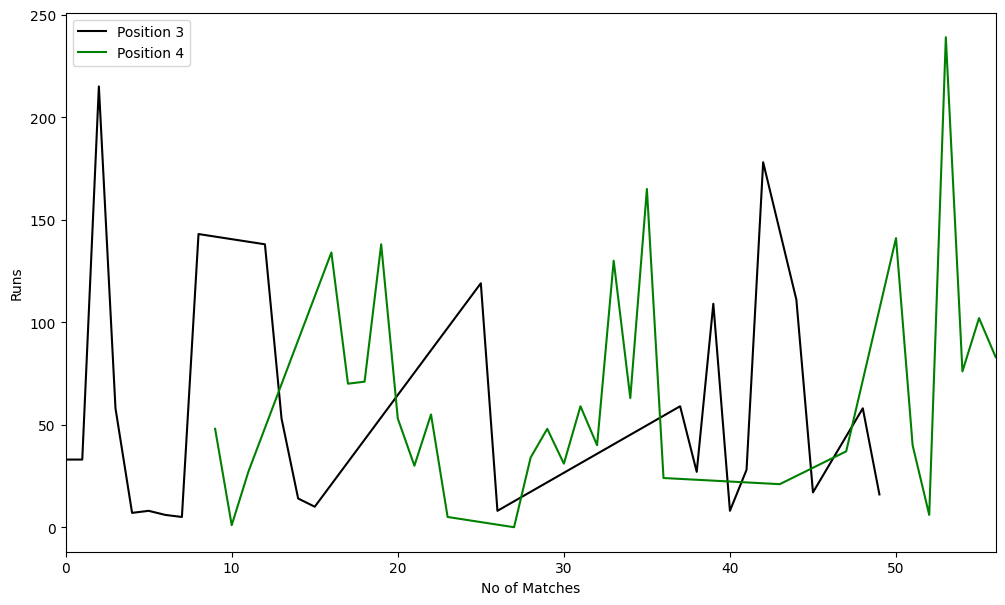

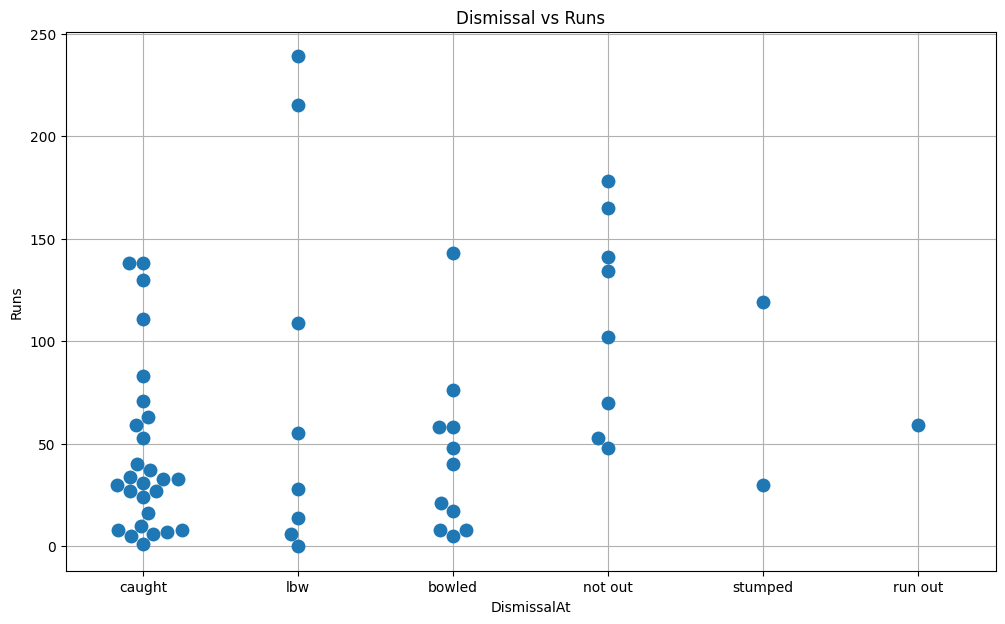

c:\Users\LENOVO T460S\AppData\Local\Programs\Python\Python37\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


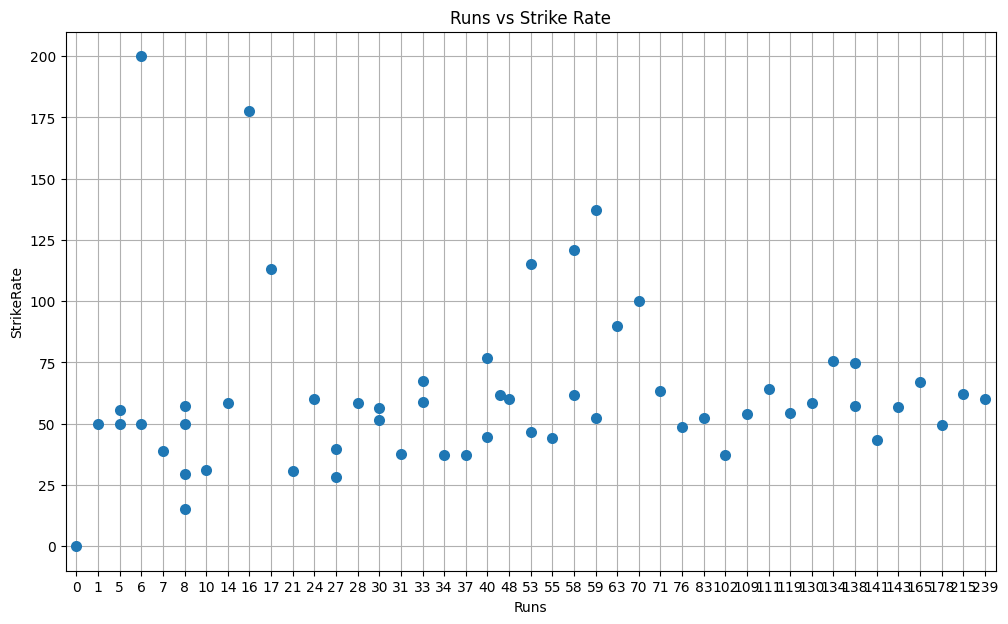

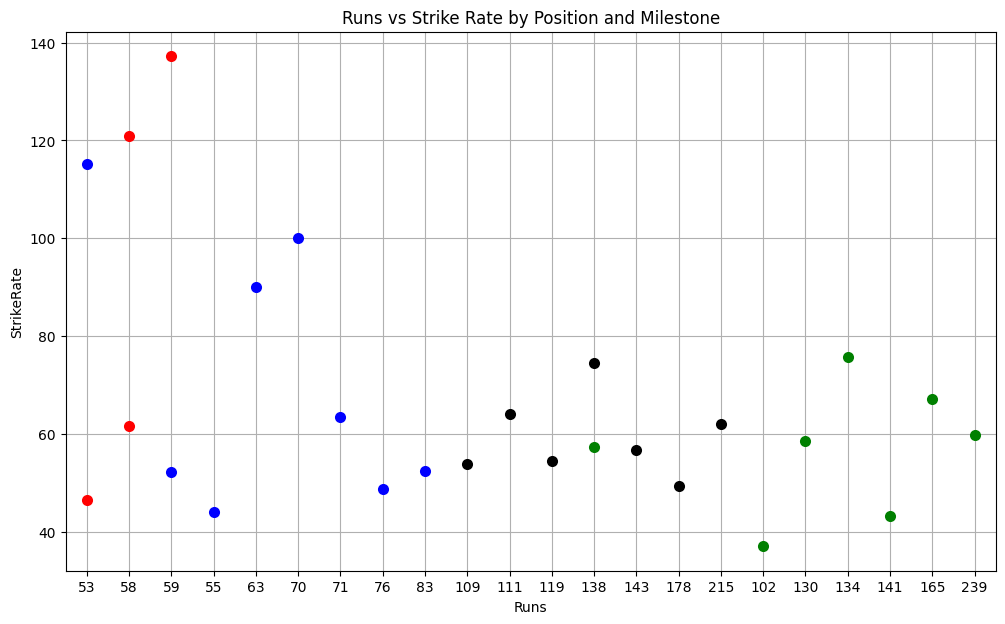

Average of Batsman 2: 57.55769230769231
Maximum of Batsman 2 in a Match: 243


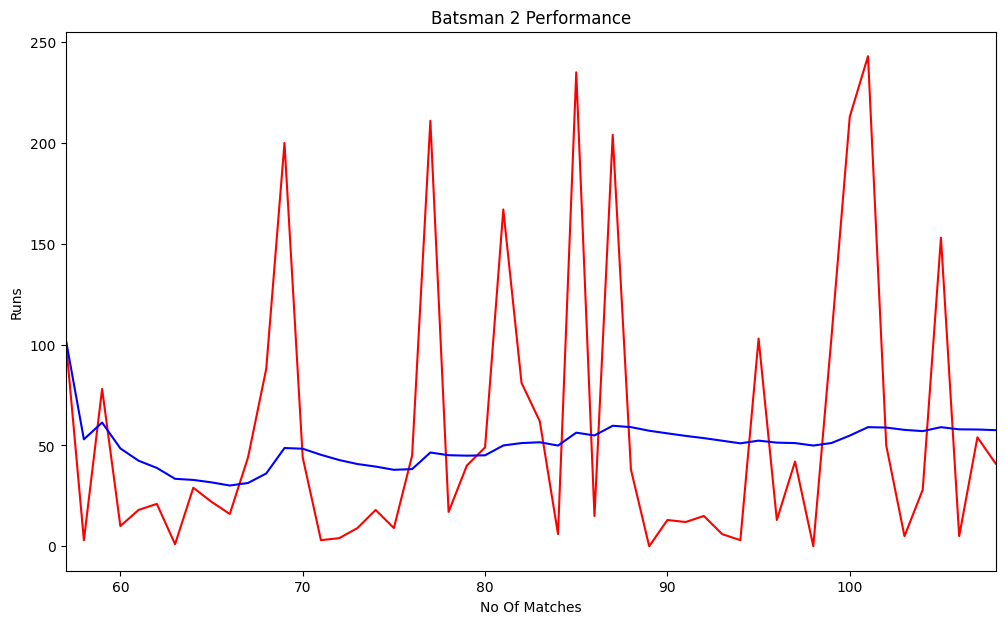

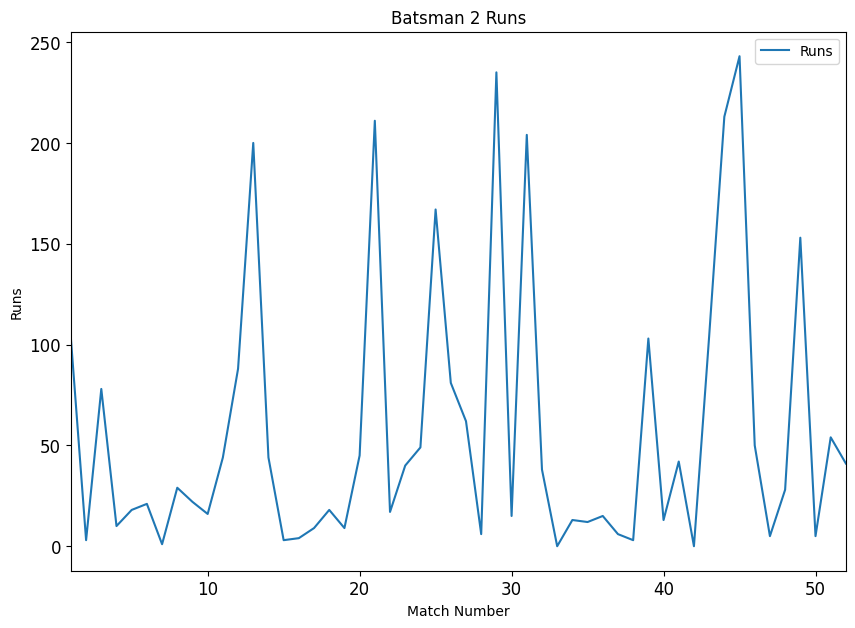

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

# Load and format dataset
matches = pd.read_csv('D:/SEM-6/Skill Dev Project/dataset1_test.csv') 
print(matches.head())
Records = pd.DataFrame(matches)
Records.columns = ['Batsman', 'Runs', 'Minute', 'Ballfaced', 'fours', 'sixes', 'StrikeRate', 'Position', 'DismissalAt', 'Innings']

# Split individual player records
batsman1 = Records[(Records.Batsman == 1)]
batsman2 = Records[(Records.Batsman == 2)]

# Average run of each player
avgOfPlayersGrpBy = Records[['Batsman', 'Runs']].groupby('Batsman').mean()
print(avgOfPlayersGrpBy)

# Plot average run of batsmen
avgOfPlayersGrpByPlot = avgOfPlayersGrpBy['Runs'].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
avgOfPlayersGrpByPlot.plot(kind='bar', color='green', title="Average run of Batsman")
plt.ylabel('Average Runs', fontsize=15, fontweight='bold')
plt.show()

# Run from fours and sixes
runBysixFour = Records[['Batsman', 'fours', 'sixes', 'Runs']].groupby('Batsman').sum()
runBysixFour['runByFour'] = runBysixFour['fours'] * 4
runBysixFour['runBySix'] = runBysixFour['sixes'] * 6
runBysixFour['totalRunFromBoundary'] = runBysixFour['runByFour'] + runBysixFour['runBySix']
print(runBysixFour)

# Plot run from boundaries
plt.figure(figsize=(10, 7))
runBysixFour[['runByFour', 'runBySix']].plot(kind='bar', stacked=True)
plt.title("Run from Fours and Sixes")
plt.show()

# Batsman 1 analysis
batsman1_run = batsman1['Runs']
print('Average of Batsman 1:', batsman1_run.mean())
print('Maximum of Batsman 1 in a Match:', batsman1_run.max())

plt.figure(figsize=(10, 7))
batsman1_run.plot(color='red')
plt.plot([0, batsman1_run.count()], [batsman1_run.mean()] * 2, color='blue')
plt.xlabel('No Of Matches')
plt.ylabel('Runs')
plt.show()

# Average run of each consecutive match for Batsman 1
batsman1_avg = []
for i, row in enumerate(batsman1_run):
    if i == 0:
        batsman1_avg.append(row)
    else:
        value = (batsman1_avg[i-1]*i + row) / (i+1)
        batsman1_avg.append(value)

batsman1 = batsman1.copy()
batsman1['avgRunPerMatch'] = batsman1_avg

plt.figure(figsize=(12, 7))
batsman1['Runs'].plot(color='red')
batsman1['avgRunPerMatch'].plot(color='blue')
plt.plot([0, batsman1_run.count()], [batsman1_run.mean()] * 2, color='green')
plt.xlabel('No Of Matches')
plt.ylabel('Runs')
plt.show()

# Pie chart: Run distribution
sizes = [batsman1['fours'].sum() * 4, batsman1['sixes'].sum() * 6,
         batsman1['Runs'].sum() - (batsman1['fours'].sum() * 4 + batsman1['sixes'].sum() * 6)]
labels = ['Fours', 'Sixes', 'Others']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.show()

# Pie chart: Dismissal methods
dismissal_counts = batsman1['DismissalAt'].value_counts()
plt.pie(dismissal_counts.values, labels=dismissal_counts.index, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.show()

# Position based analysis
for pos in [3, 4]:
    pos_data = batsman1[batsman1['Position'] == pos]
    print(f"--- Position {pos} ---")
    print("Matches:", pos_data['Runs'].count())
    print("Average:", pos_data['Runs'].mean())
    print("Total Runs:", pos_data['Runs'].sum())
    print("Average Strike Rate:", pos_data['StrikeRate'].mean(), "\n")

# Run comparison at different positions
plt.figure(figsize=(12, 7))
batsman1[batsman1['Position'] == 3]['Runs'].plot(label='Position 3', color='black')
batsman1[batsman1['Position'] == 4]['Runs'].plot(label='Position 4', color='green')
plt.xlabel("No of Matches")
plt.ylabel("Runs")
plt.legend()
plt.show()

# Swarmplots
plt.figure(figsize=(12, 7))
sns.swarmplot(y="Runs", x="DismissalAt", size=10, data=batsman1)
plt.title("Dismissal vs Runs")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 7))
sns.swarmplot(y="StrikeRate", x="Runs", size=8, data=batsman1)
plt.title("Runs vs Strike Rate")
plt.grid(True)
plt.show()

# Advanced swarmplot with coloring by condition
plt.figure(figsize=(12, 7))
sns.swarmplot(y="StrikeRate", x="Runs", size=8, color='red', data=batsman1[(batsman1.Position == 3) & (batsman1.Runs >= 50) & (batsman1.Runs < 100)])
sns.swarmplot(y="StrikeRate", x="Runs", size=8, color='blue', data=batsman1[(batsman1.Position == 4) & (batsman1.Runs >= 50) & (batsman1.Runs < 100)])
sns.swarmplot(y="StrikeRate", x="Runs", size=8, color='black', data=batsman1[(batsman1.Position == 3) & (batsman1.Runs >= 100)])
sns.swarmplot(y="StrikeRate", x="Runs", size=8, color='green', data=batsman1[(batsman1.Position == 4) & (batsman1.Runs >= 100)])
plt.title("Runs vs Strike Rate by Position and Milestone")
plt.grid(True)
plt.show()

# Batsman 2 analysis
batsman2_run = batsman2['Runs']
batsman2_avg = []
match_no = []
for i, row in enumerate(batsman2_run):
    match_no.append(i+1)
    if i == 0:
        batsman2_avg.append(row)
    else:
        value = (batsman2_avg[i-1]*i + row) / (i+1)
        batsman2_avg.append(value)

batsman2 = batsman2.copy()
batsman2['avgRunPerMatch'] = batsman2_avg
batsman2['match_no'] = match_no

print('Average of Batsman 2:', batsman2_run.mean())
print('Maximum of Batsman 2 in a Match:', batsman2_run.max())

plt.figure(figsize=(12, 7))
batsman2['Runs'].plot(color='red')
batsman2['avgRunPerMatch'].plot(color='blue')
plt.plot([0, batsman2_run.count()], [batsman2_run.mean()] * 2, color='green')
plt.xlabel('No Of Matches')
plt.ylabel('Runs')
plt.title("Batsman 2 Performance")
plt.show()

batsman2.plot(kind='line', x='match_no', y='Runs', title="Batsman 2 Runs", figsize=(10, 7), legend=True, fontsize=12)
plt.xlabel('Match Number')
plt.ylabel('Runs')
plt.show()






Predicted Runs for Future Matches:
    match_no  Predicted Runs
0        53       76.499705
1        54       77.213389
2        55       77.927073
3        56       78.640756
4        57       79.354440


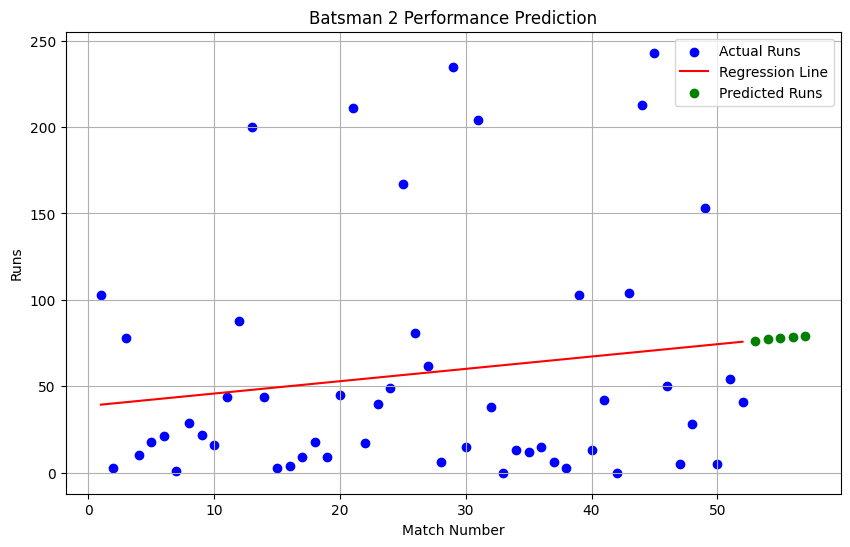

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Prepare features (X) and target (y)
X = batsman2[['match_no']]  # match number as independent variable
y = batsman2['Runs']        # runs scored as dependent variable

# Split data for training and testing (optional)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict runs for next 5 matches
future_matches = pd.DataFrame({'match_no': [batsman2['match_no'].max() + i for i in range(1, 6)]})
predicted_runs = model.predict(future_matches)

# Show predictions
predicted_df = future_matches.copy()
predicted_df['Predicted Runs'] = predicted_runs
print("\nPredicted Runs for Future Matches:\n", predicted_df)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Runs')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.scatter(future_matches, predicted_runs, color='green', label='Predicted Runs')
plt.xlabel('Match Number')
plt.ylabel('Runs')
plt.title("Batsman 2 Performance Prediction")
plt.legend()
plt.grid(True)
plt.show()
